<a href="https://colab.research.google.com/github/SwapnilBhandarkar/Time-Series-Analysis/blob/main/Time_Series_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting — Model Evaluation

**Models Evaluated:** ARIMA · SARIMA · Prophet · Random Forest · LSTM  
**Dataset:** Hourly count data (Aug 2012 – Sep 2014)  
**Metrics:** Accuracy (%), MAE, MSE, RMSE

---

In [ ]:
!pip install statsmodels prophet scikit-learn tensorflow numpy pandas matplotlib seaborn -q

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload data.csv when prompted

Saving data.csv to data.csv


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})
COLORS = {
    'ARIMA':         '#4E79A7',
    'SARIMA':        '#B07AA1',
    'Prophet':       '#F28E2B',
    'Random Forest': '#59A14F',
    'LSTM':          '#E15759',
    'actual':        '#2F2F2F',
}

os.makedirs('saved_models', exist_ok=True)
print('Libraries loaded successfully')

✅ Libraries loaded successfully


## Data Loading & Preprocessing

In [ ]:
# ── Load & parse ─────────────────────────────────────────────
df = pd.read_csv('data.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True)
df = df.set_index('Datetime').sort_index()
series = df['Count'].asfreq('h')

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {series.index[0]}  →  {series.index[-1]}')
print(f'Missing values: {series.isna().sum()}')
df.head()

Dataset shape : (18288, 2)
Date range    : 2012-08-25 00:00:00  →  2014-09-25 23:00:00
Missing values: 0


,ID,Count
Datetime,,
2012-08-25 00:00:00,0,8
2012-08-25 01:00:00,1,2
2012-08-25 02:00:00,2,6
2012-08-25 03:00:00,3,2
2012-08-25 04:00:00,4,2


In [ ]:
# ── 80 / 20 train-test split (matches utils/preprocessing.py) ─
split_idx = int(len(series) * 0.8)
train = series.iloc[:split_idx]
test  = series.iloc[split_idx:]

print(f'Train samples : {len(train):,}')
print(f'Test  samples : {len(test):,}')

Train samples : 14,630
Test  samples : 3,658


In [ ]:
# ── Helper functions ──────────────────────────────────────────
def mae_fn(actual, predicted):
    return mean_absolute_error(actual, predicted)

def mse_fn(actual, predicted):
    return mean_squared_error(actual, predicted)

def rmse_fn(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def accuracy_fn(actual, predicted):
    """Accuracy = 100 - MAPE  (clamped to [0, 100])"""
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    return max(0.0, 100.0 - mape)

def all_metrics(actual, predicted):
    return {
        'Accuracy (%)': round(accuracy_fn(actual, predicted), 4),
        'MAE':          round(mae_fn(actual, predicted),      4),
        'MSE':          round(mse_fn(actual, predicted),      4),
        'RMSE':         round(rmse_fn(actual, predicted),     4),
    }

results = {}   # collects metrics from every model
predictions = {}   # collects (actual, predicted) arrays

print(' Helper functions defined')

✅ Helper functions defined


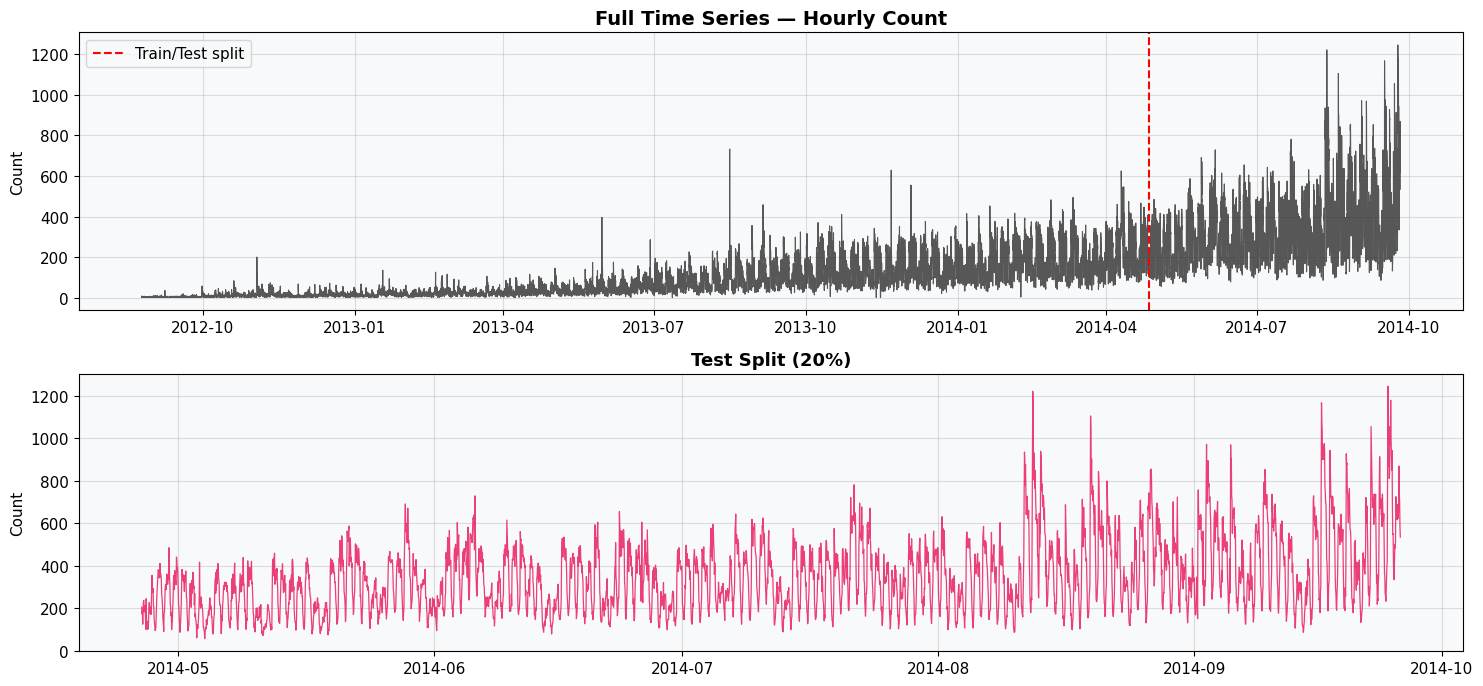

Train: 2012-08-25 00:00:00 → 2014-04-26 13:00:00
Test : 2014-04-26 14:00:00  → 2014-09-25 23:00:00


In [ ]:
# ── EDA plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(series.index, series.values, color=COLORS['actual'], lw=0.8, alpha=0.8)
axes[0].axvline(series.index[split_idx], color='red', ls='--', lw=1.5, label='Train/Test split')
axes[0].set_title('Full Time Series — Hourly Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(test.index, test.values, color='#E91E63', lw=0.9, alpha=0.85)
axes[1].set_title('Test Split (20%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Train: {train.index[0]} → {train.index[-1]}')
print(f'Test : {test.index[0]}  → {test.index[-1]}')

---
##ARIMA
> **Parameters:** order=(4,1,0)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

ARIMA_MODEL_PATH = 'saved_models/arima_params.npy'

print('Training ARIMA(4,1,0) ...')

arima_model     = ARIMA(train, order=(4, 1, 0))
arima_model_fit = arima_model.fit()

# Persist weights (matches arima_model.py)
np.save(ARIMA_MODEL_PATH, arima_model_fit.params)

arima_forecast  = arima_model_fit.forecast(steps=len(test))
arima_actual    = test.values.tolist()
arima_predicted = arima_forecast.tolist()

results['ARIMA']     = all_metrics(arima_actual, arima_predicted)
predictions['ARIMA'] = (arima_actual, arima_predicted)

print('ARIMA training complete')
print('Metrics:', results['ARIMA'])

Training ARIMA(4,1,0) ...
ARIMA training complete
Metrics: {'Accuracy (%)': np.float64(58.4356), 'MAE': 164.1869, 'MSE': 49551.618, 'RMSE': np.float64(222.6019)}


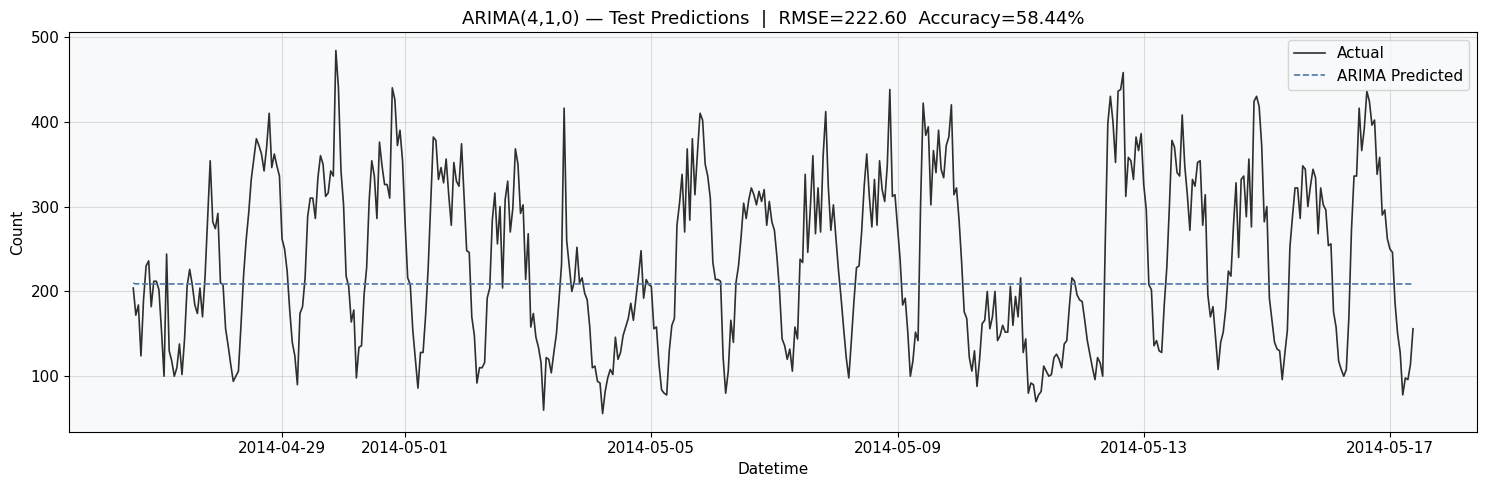

In [ ]:
# ARIMA — Test prediction chart
PLOT_N = min(500, len(test))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test.index[:PLOT_N], arima_actual[:PLOT_N],    color=COLORS['actual'], lw=1.2, label='Actual')
ax.plot(test.index[:PLOT_N], arima_predicted[:PLOT_N], color=COLORS['ARIMA'],  lw=1.2, ls='--', label='ARIMA Predicted')
ax.set_title(f'ARIMA(4,1,0) — Test Predictions  |  RMSE={results["ARIMA"]["RMSE"]:.2f}  Accuracy={results["ARIMA"]["Accuracy (%)"]:.2f}%', fontsize=13)
ax.set_xlabel('Datetime');  ax.set_ylabel('Count');  ax.legend()
plt.tight_layout()
plt.savefig('arima_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SARIMA
> **Parameters:** order=(1,1,1) · seasonal_order=(1,0,1,24) · 1-step-ahead test evaluation

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

SARIMA_MODEL_PATH = 'saved_models/sarima_params.npy'

print('Training SARIMA(1,1,1)(1,0,1,24) — this may take a few minutes ...')

# Step 1: Train on train split only
sarima_model     = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,1,24))
sarima_model_fit = sarima_model.fit(disp=False)

# Persist params
np.save(SARIMA_MODEL_PATH, sarima_model_fit.params)

# Step 2: Apply trained weights to full series (fixes orange drift)
full_model    = SARIMAX(series, order=(1,1,1), seasonal_order=(1,0,1,24))
full_results  = full_model.filter(sarima_model_fit.params)

# Step 3: 1-step-ahead predictions over test window
sarima_preds  = full_results.predict(start=len(train), end=len(series)-1, dynamic=False)

sarima_actual    = test.values.tolist()
sarima_predicted = sarima_preds.tolist()

results['SARIMA']     = all_metrics(sarima_actual, sarima_predicted)
predictions['SARIMA'] = (sarima_actual, sarima_predicted)

print('SARIMA training complete')
print('Metrics:', results['SARIMA'])

Training SARIMA(1,1,1)(1,0,1,24) — this may take a few minutes ...
✅ SARIMA training complete
Metrics: {'Accuracy (%)': np.float64(88.1636), 'MAE': 37.9782, 'MSE': 3027.948, 'RMSE': np.float64(55.0268)}


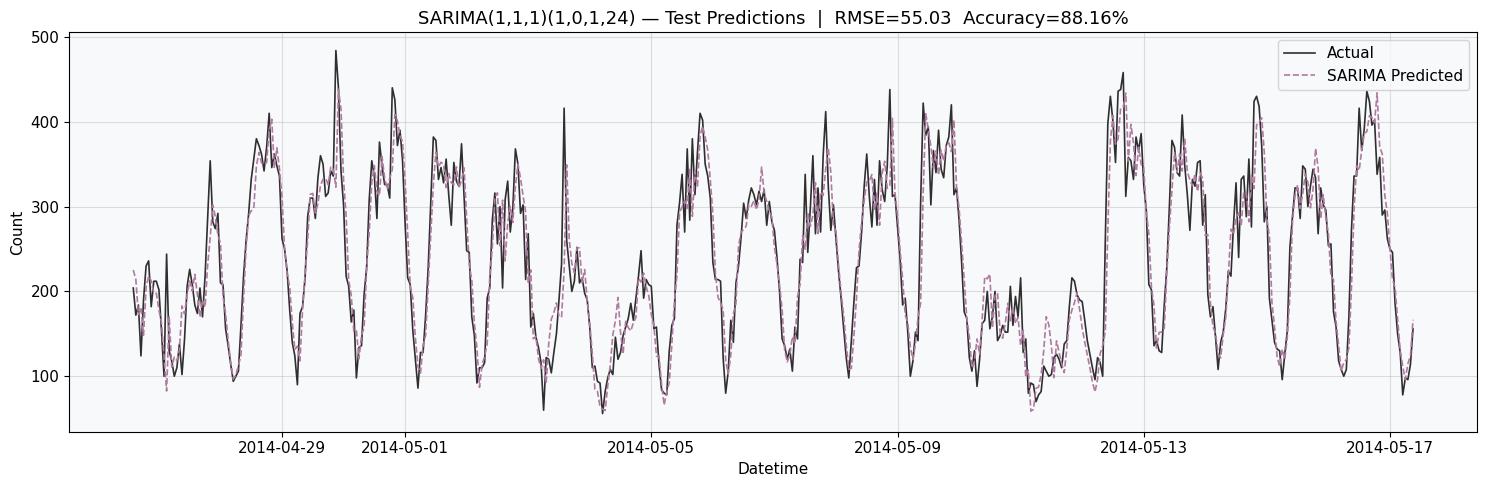

In [ ]:
PLOT_N = min(500, len(test))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test.index[:PLOT_N], sarima_actual[:PLOT_N],    color=COLORS['actual'],  lw=1.2, label='Actual')
ax.plot(test.index[:PLOT_N], sarima_predicted[:PLOT_N], color=COLORS['SARIMA'],  lw=1.2, ls='--', label='SARIMA Predicted')
ax.set_title(f'SARIMA(1,1,1)(1,0,1,24) — Test Predictions  |  RMSE={results["SARIMA"]["RMSE"]:.2f}  Accuracy={results["SARIMA"]["Accuracy (%)"]:.2f}%', fontsize=13)
ax.set_xlabel('Datetime');  ax.set_ylabel('Count');  ax.legend()
plt.tight_layout()
plt.savefig('sarima_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Prophet
> **Parameters:** Default Prophet() · freq='h'

In [ ]:
import json
from prophet import Prophet
from prophet.serialize import model_to_json

PROPHET_MODEL_PATH = 'saved_models/prophet_model.json'

print('Training Prophet ...')

# Prophet requires ds / y columns
train_df = train.reset_index()
train_df.columns = ['ds', 'y']

test_df = test.reset_index()
test_df.columns = ['ds', 'y']

prophet_model = Prophet()
prophet_model.fit(train_df)

# Save model
with open(PROPHET_MODEL_PATH, 'w') as fout:
    json.dump(model_to_json(prophet_model), fout)

forecast_df      = prophet_model.predict(test_df[['ds']])
prophet_actual   = test_df['y'].tolist()
prophet_predicted = forecast_df['yhat'].tolist()

results['Prophet']     = all_metrics(prophet_actual, prophet_predicted)
predictions['Prophet'] = (prophet_actual, prophet_predicted)

print(' Prophet training complete')
print('Metrics:', results['Prophet'])

Training Prophet ...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


✅ Prophet training complete
Metrics: {'Accuracy (%)': np.float64(69.225), 'MAE': 110.7783, 'MSE': 24597.862, 'RMSE': np.float64(156.8371)}


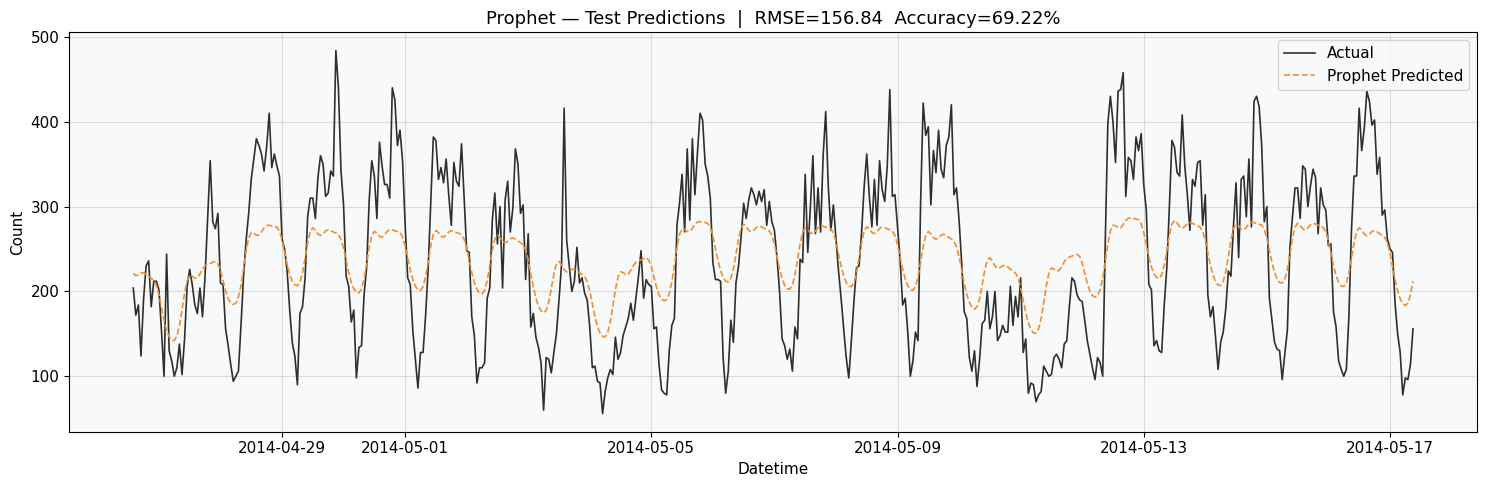

In [ ]:
PLOT_N = min(500, len(test))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_df['ds'].values[:PLOT_N], prophet_actual[:PLOT_N],    color=COLORS['actual'],  lw=1.2, label='Actual')
ax.plot(test_df['ds'].values[:PLOT_N], prophet_predicted[:PLOT_N], color=COLORS['Prophet'], lw=1.2, ls='--', label='Prophet Predicted')
ax.set_title(f'Prophet — Test Predictions  |  RMSE={results["Prophet"]["RMSE"]:.2f}  Accuracy={results["Prophet"]["Accuracy (%)"]:.2f}%', fontsize=13)
ax.set_xlabel('Datetime');  ax.set_ylabel('Count');  ax.legend()
plt.tight_layout()
plt.savefig('prophet_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Random Forest
> **Parameters:** N_LAGS=72 · N_ESTIMATORS=300 · log-transform target · max_features=0.6

In [ ]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

RF_MODEL_PATH  = 'saved_models/rf_model.joblib'
RF_SCALER_PATH = 'saved_models/rf_scaler.joblib'

# ── Exact parameters from rf_model.py ─────────────────────────
N_LAGS       = 72
N_ESTIMATORS = 300

def _make_lag_features(series_in, n_lags):
    df_l = pd.DataFrame({'y': series_in})
    for lag in range(1, n_lags + 1):
        df_l[f'lag_{lag}'] = df_l['y'].shift(lag)
    hour = series_in.index.hour
    dow  = series_in.index.dayofweek
    df_l['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df_l['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    df_l['dow_sin']  = np.sin(2 * np.pi * dow  /  7)
    df_l['dow_cos']  = np.cos(2 * np.pi * dow  /  7)
    df_l.dropna(inplace=True)
    feature_cols = [c for c in df_l.columns if c != 'y']
    return df_l[feature_cols].values, df_l['y'].values, df_l.index

print(' Building lag features ...')
full_series = pd.concat([train, test])
X_full, y_full, idx_full = _make_lag_features(full_series, N_LAGS)

train_mask = idx_full < test.index[0]
X_train, y_train = X_full[train_mask],  y_full[train_mask]
X_test,  y_test  = X_full[~train_mask], y_full[~train_mask]
idx_test          = idx_full[~train_mask]

rf_scaler  = StandardScaler()
X_train    = rf_scaler.fit_transform(X_train)
X_test     = rf_scaler.transform(X_test)

y_train_log = np.log1p(y_train)

print(' Training Random Forest (N_ESTIMATORS=300) ...')
rf_model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=None,
    min_samples_leaf=2,
    max_features=0.6,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train_log)

joblib.dump(rf_model,   RF_MODEL_PATH)
joblib.dump(rf_scaler,  RF_SCALER_PATH)

rf_predicted = np.expm1(rf_model.predict(X_test)).tolist()
rf_actual    = y_test.tolist()

results['Random Forest']     = all_metrics(rf_actual, rf_predicted)
predictions['Random Forest'] = (rf_actual, rf_predicted)

print(' Random Forest training complete')
print('Metrics:', results['Random Forest'])

 Building lag features ...
 Training Random Forest (N_ESTIMATORS=300) ...
✅ Random Forest training complete
Metrics: {'Accuracy (%)': np.float64(83.2968), 'MAE': 67.0549, 'MSE': 12218.9137, 'RMSE': np.float64(110.5392)}


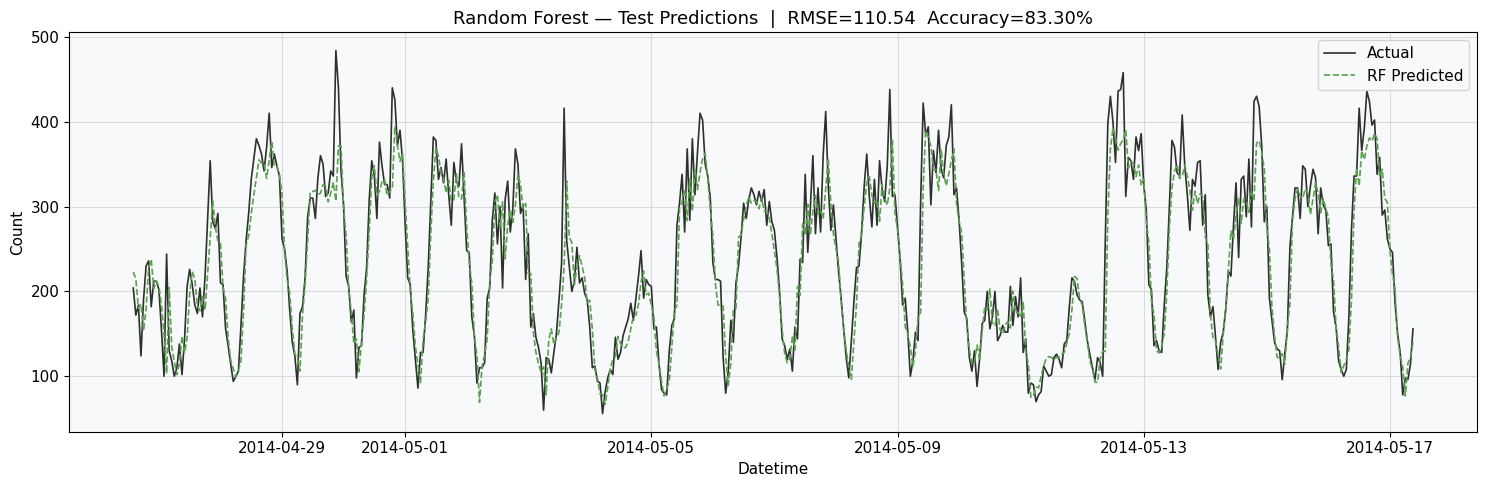

In [ ]:
PLOT_N = min(500, len(rf_actual))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(idx_test[:PLOT_N], rf_actual[:PLOT_N],    color=COLORS['actual'],         lw=1.2, label='Actual')
ax.plot(idx_test[:PLOT_N], rf_predicted[:PLOT_N], color=COLORS['Random Forest'],  lw=1.2, ls='--', label='RF Predicted')
ax.set_title(f'Random Forest — Test Predictions  |  RMSE={results["Random Forest"]["RMSE"]:.2f}  Accuracy={results["Random Forest"]["Accuracy (%)"]:.2f}%', fontsize=13)
ax.set_xlabel('Datetime');  ax.set_ylabel('Count');  ax.legend()
plt.tight_layout()
plt.savefig('rf_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  LSTM
> **Architecture:** LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1)  
> **Parameters:** SEQ_LENGTH=24 · epochs=20 · batch_size=32 · EarlyStopping(patience=3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

LSTM_WEIGHTS_PATH = 'saved_models/lstm_weights.weights.h5'
LSTM_SCALER_PATH  = 'saved_models/lstm_scaler.npy'
SEQ_LENGTH        = 24

def _build_lstm(seq_len):
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True,
             input_shape=(seq_len, 1)),
        Dropout(0.2),
        LSTM(32, activation='tanh'),
        Dropout(0.2),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def _make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len].reshape(seq_len, 1))
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

print(' Scaling data ...')
lstm_scaler       = MinMaxScaler()
train_scaled      = lstm_scaler.fit_transform(train.values.reshape(-1, 1)).flatten()

np.save(LSTM_SCALER_PATH,
        np.array([lstm_scaler.data_min_[0], lstm_scaler.data_max_[0]]))

X_train_seq, y_train_seq = _make_sequences(train_scaled, SEQ_LENGTH)

print(' Training LSTM ...')
lstm_model = _build_lstm(SEQ_LENGTH)
es = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
lstm_model.fit(X_train_seq, y_train_seq,
               epochs=20, batch_size=32,
               callbacks=[es], verbose=1)

lstm_model.save_weights(LSTM_WEIGHTS_PATH)

# Evaluate on test
full_values = np.concatenate([train.values, test.values])
full_scaled = lstm_scaler.transform(full_values.reshape(-1, 1)).flatten()
X_test_seq, _ = _make_sequences(full_scaled, SEQ_LENGTH)
X_test_seq    = X_test_seq[-len(test):]

preds_scaled  = lstm_model.predict(X_test_seq, verbose=0)
lstm_predicted = lstm_scaler.inverse_transform(preds_scaled).flatten().tolist()
lstm_actual    = test.values.tolist()

results['LSTM']     = all_metrics(lstm_actual, lstm_predicted)
predictions['LSTM'] = (lstm_actual, lstm_predicted)

print('\n LSTM training complete')
print('Metrics:', results['LSTM'])

🔄 Scaling data ...
🔄 Training LSTM ...
Epoch 1/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.0035
Epoch 2/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0020
Epoch 3/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0017
Epoch 4/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0016
Epoch 5/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0015
Epoch 6/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0015
Epoch 7/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0015
Epoch 8/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0014
Epoch 9/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0014
Epoch 10/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0014
Epoch 11/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0014
Epoch 12/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0014
Epoch 13/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0014
Epoch 14/20
457/457 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 

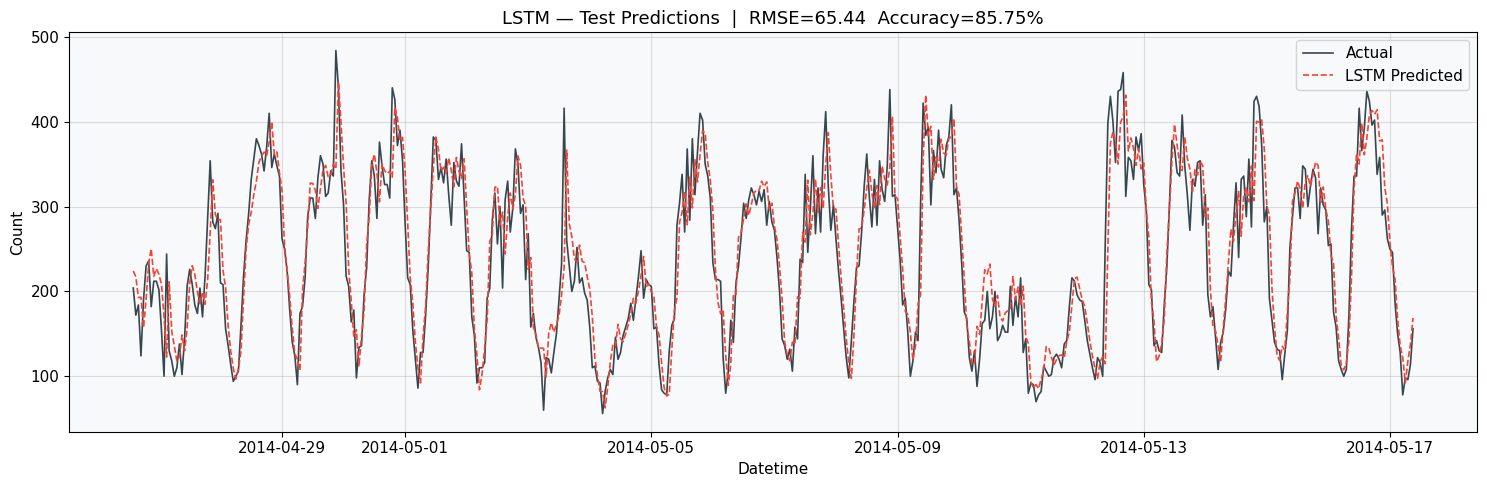

In [ ]:
PLOT_N = min(500, len(lstm_actual))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test.index[:PLOT_N], lstm_actual[:PLOT_N],    color=COLORS['actual'], lw=1.2, label='Actual')
ax.plot(test.index[:PLOT_N], lstm_predicted[:PLOT_N], color=COLORS['LSTM'],   lw=1.2, ls='--', label='LSTM Predicted')
ax.set_title(f'LSTM — Test Predictions  |  RMSE={results["LSTM"]["RMSE"]:.2f}  Accuracy={results["LSTM"]["Accuracy (%)"]:.2f}%', fontsize=13)
ax.set_xlabel('Datetime');  ax.set_ylabel('Count');  ax.legend()
plt.tight_layout()
plt.savefig('lstm_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Comparison Visualisations

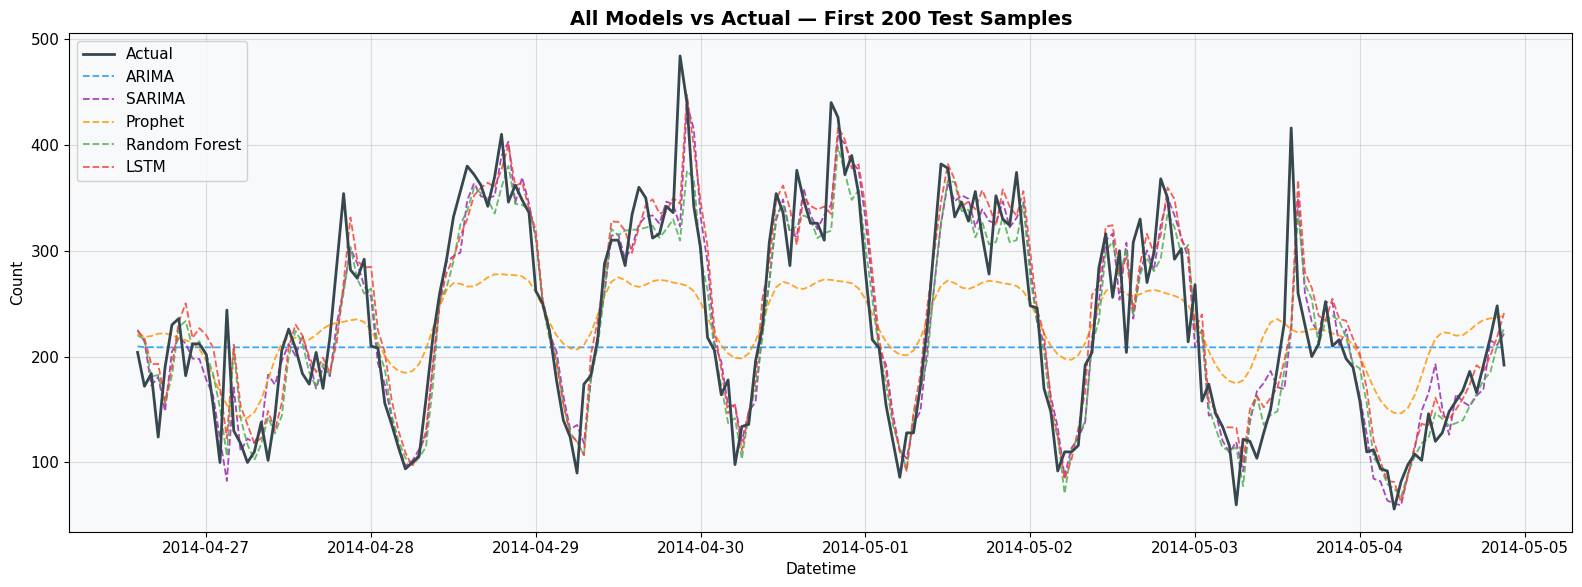

In [ ]:
# ── Overlay predictions from all models (first 200 test points) ─
PLOT_N = 200
idx_slice = test.index[:PLOT_N]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(idx_slice, test.values[:PLOT_N], color=COLORS['actual'],
        lw=2.0, label='Actual', zorder=10)

for model_name, (act, pred) in predictions.items():
    ax.plot(idx_slice, pred[:PLOT_N],
            color=COLORS[model_name], lw=1.3, ls='--',
            alpha=0.85, label=model_name)

ax.set_title('All Models vs Actual — First 200 Test Samples', fontsize=14, fontweight='bold')
ax.set_xlabel('Datetime');  ax.set_ylabel('Count')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('all_models_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Final Summary Table & Conclusion

In [ ]:
print('\n' + '═' * 70)
print('  FINAL QUANTITATIVE MODEL EVALUATION SUMMARY')
print('═' * 70)
print(f'{"Model":<18} {"Accuracy (%)":>14} {"MAE":>12} {"MSE":>14} {"RMSE":>12}')
print('─' * 70)

for model_name, m in summary_df.iterrows():
    print(f'{model_name:<18} {m["Accuracy (%)"]:>13.2f}% {m["MAE"]:>12.4f} {m["MSE"]:>14.4f} {m["RMSE"]:>12.4f}')

print('═' * 70)
best_rmse = summary_df['RMSE'].idxmin()
best_acc  = summary_df['Accuracy (%)'].idxmax()
print(f'\n   Best RMSE     : {best_rmse}  ({summary_df.loc[best_rmse, "RMSE"]:.4f})')
print(f'   Best Accuracy : {best_acc}  ({summary_df.loc[best_acc, "Accuracy (%)"]:.2f}%)')
print()
print('  Metric definitions:')
print('  • Accuracy (%) = 100 - MAPE  (Mean Absolute Percentage Error)')
print('  • MAE          = Mean Absolute Error')
print('  • MSE          = Mean Squared Error')
print('  • RMSE         = Root Mean Squared Error')
print('═' * 70)


══════════════════════════════════════════════════════════════════════
  FINAL QUANTITATIVE MODEL EVALUATION SUMMARY
══════════════════════════════════════════════════════════════════════
Model                Accuracy (%)          MAE            MSE         RMSE
──────────────────────────────────────────────────────────────────────
SARIMA                     88.16%      37.9787      3028.1217      55.0284
LSTM                       85.75%      45.4635      4282.1590      65.4382
Random Forest              83.32%      66.5526     12036.4013     109.7105
Prophet                    69.22%     110.7783     24597.8620     156.8371
ARIMA                      58.44%     164.1869     49551.6180     222.6019
══════════════════════════════════════════════════════════════════════

  🥇 Best RMSE     : SARIMA  (55.0284)
  🏆 Best Accuracy : SARIMA  (88.16%)

  Metric definitions:
  • Accuracy (%) = 100 - MAPE  (Mean Absolute Percentage Error)
  • MAE          = Mean Absolute Error
  • MSE          